In [8]:
import pickle
with open('df_ma.pickle', 'rb') as f:
    df_ma = pickle.load(f)
print(list(df_ma.columns))

['key', 'poverty_p', 'uninsured_rate', 'plumbing_lack_rate', 'A_Score', 'A_Ratio', 'A_Density', 'V_Density', 'limited_english_rate', 'renter_rate', 'low_education_rate', 'before1970_rate', 'year_mean', 'overcrowd_all', 'overcrowd_own', 'overcrowd_rent', 'holc_num', 'Y', 'ndvi_diff', 'social', 'ndvi_holc', 'gray', 'ndvi_diff_c', 'ndvi_diff_sq', 'name']


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, kruskal, f_oneway
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False

In [10]:
disease = pd.read_csv("E:/26-1 수업/다변량/캡스톤/데이터/설명변수 후보/disease2.csv")

In [12]:
disease['key'] = (
    disease['geoid']
    .astype('Int64')
    .astype(str)
    .str.zfill(11)
)

df_ma['key'] = df_ma['key'].astype(str).str.zfill(11)

di_mer = df_ma.merge(disease, on='key', how='left')

In [13]:
print(list(di_mer.columns))

['key', 'poverty_p', 'uninsured_rate', 'plumbing_lack_rate', 'A_Score', 'A_Ratio', 'A_Density', 'V_Density', 'limited_english_rate', 'renter_rate', 'low_education_rate', 'before1970_rate', 'year_mean', 'overcrowd_all', 'overcrowd_own', 'overcrowd_rent', 'holc_num', 'Y', 'ndvi_diff', 'social', 'ndvi_holc', 'gray', 'ndvi_diff_c', 'ndvi_diff_sq', 'name', 'geoid', 'TotalPopulation', '성인건강보험미가입률', '성인관절염', '폭음', '고혈압', '비피부암', '천식', '관상동맥심장질환', '건강검진(정기)', '콜레스테롤', '대장암검진률', '만성폐쇄성폐질환', '흡연률(현재)', '치과방문률', '우울증', '당뇨', '평균이하의건강', '고콜레스테롤혈증', '여가시간신체활동부족률', '정신적고통', '비만도', '신체적고통', '수면부족', '뇌졸증', '치아상실', '청각장애', '시력장애', '인지장애', '이동장애', '자기관리장애', '자립생활장애', '장애', '외로움', '푸드스탬프수령률', '식량불안정경험률', '주거불안정경험률', '공공서비스위협경험률', '교통수단부족경험률', '사회적지원부족경험률']


In [21]:
df_di = di_mer[['key', 'holc_num', 'Y','poverty_p','ndvi_diff', 'A_Density', 'limited_english_rate', 'uninsured_rate',
'성인건강보험미가입률', '성인관절염', '폭음', '고혈압', '비피부암', '천식', '관상동맥심장질환', '건강검진(정기)',
 '콜레스테롤', '대장암검진률', '만성폐쇄성폐질환', '흡연률(현재)', '치과방문률', '우울증', '당뇨', '평균이하의건강',
 '고콜레스테롤혈증', '여가시간신체활동부족률', '정신적고통', '비만도', '신체적고통', '수면부족', '뇌졸증', '치아상실',
 '청각장애', '시력장애', '인지장애', '이동장애', '자기관리장애', '자립생활장애', '장애', '외로움', '푸드스탬프수령률',
 '식량불안정경험률', '주거불안정경험률', '공공서비스위협경험률', '교통수단부족경험률', '사회적지원부족경험률']]

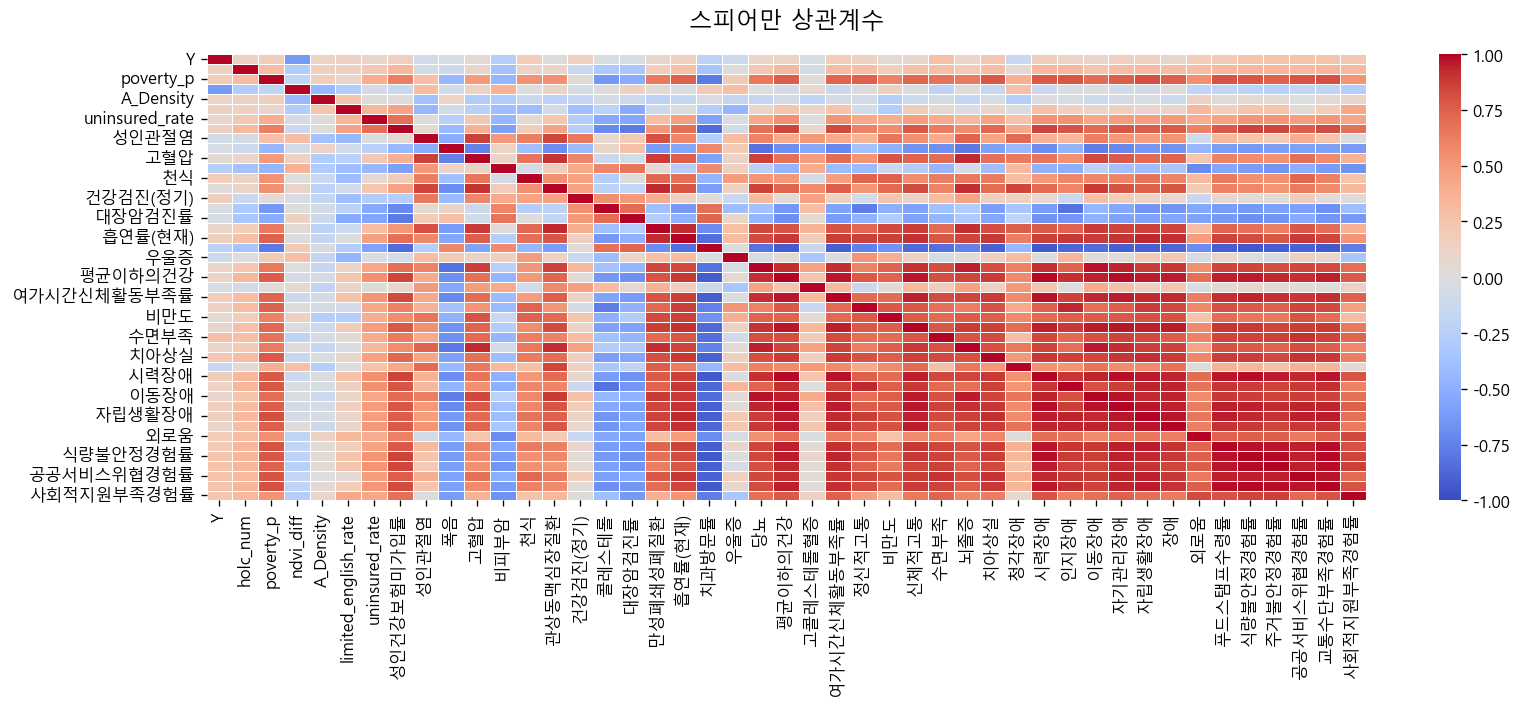

In [22]:
cols = list(df_di.columns)
cols.remove('Y')
cols.remove('key')
cols = ['Y'] + cols

spearman_table = df_di[cols].corr(method='spearman')

plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(figsize=(14, 6))
sns.heatmap(spearman_table, 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            linewidths=0.5)
axes.set_title('스피어만 상관계수', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

In [24]:
di_sel = df_di[['Y', 'ndvi_diff','poverty_p', 'holc_num','A_Density', 'limited_english_rate', 'uninsured_rate' , '천식', '건강검진(정기)','평균이하의건강','여가시간신체활동부족률', '수면부족', '자기관리장애', '자립생활장애', '외로움', '식량불안정경험률', '주거불안정경험률', '공공서비스위협경험률']]

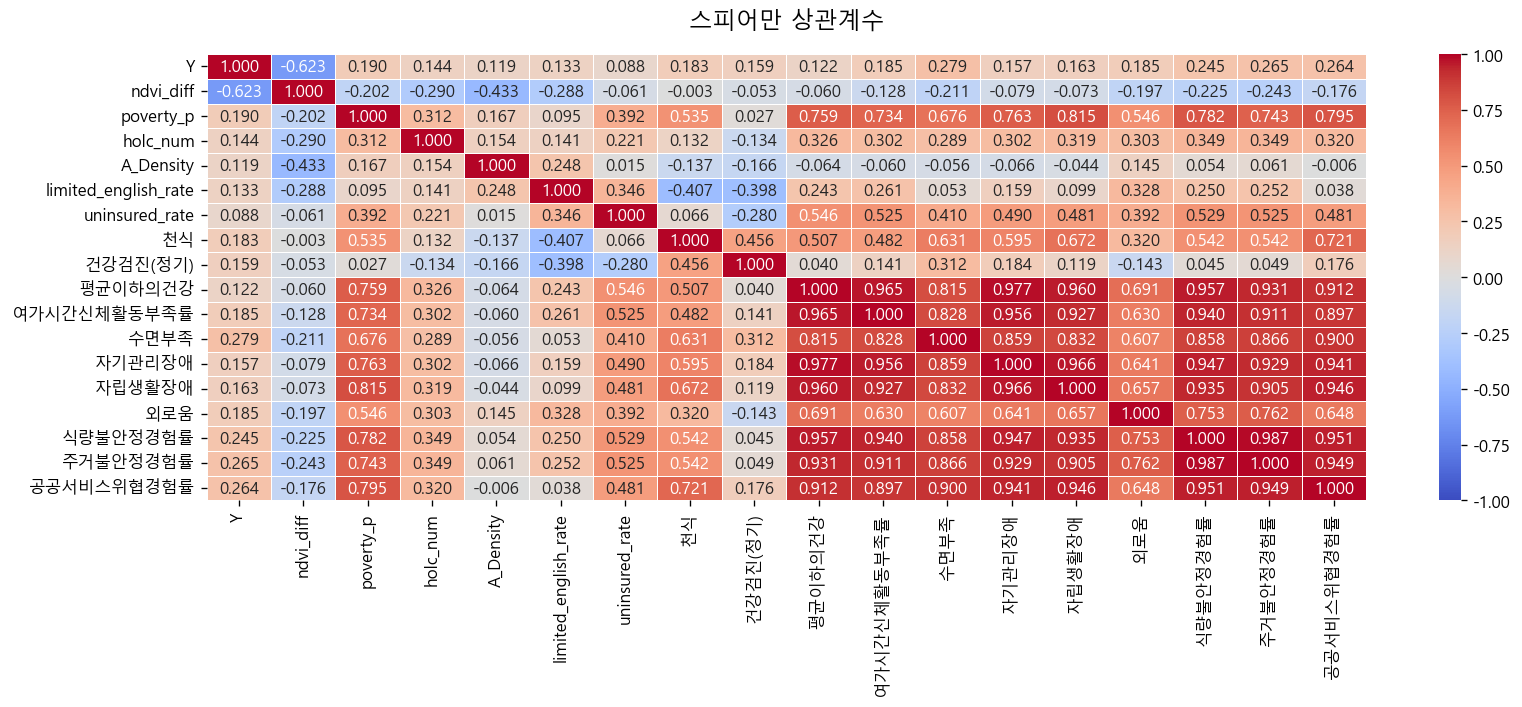

In [25]:
spearman_table = di_sel.corr(method='spearman')

plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(figsize=(14, 6))
sns.heatmap(spearman_table, 
            annot=True, 
            fmt=".3f", 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            linewidths=0.5)
axes.set_title('스피어만 상관계수', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_target = di_mer.copy()

X_features = ['Y', 'holc_num', 'ndvi_diff', 'A_Density', 'poverty_p','limited_english_rate', 'uninsured_rate'  ]
y_targets = ['천식','여가시간신체활동부족률', '수면부족', '식량불안정경험률', '주거불안정경험률', '공공서비스위협경험률']

print("=" * 60)
print("🚀 3차 보건 질병 OLS 회귀분석 실행 결과")
print("=" * 60)

for y_col in y_targets:
    # 결측치 정제
    clean_df = df_target[[y_col] + X_features].dropna()
    
    X = clean_df[X_features]
    y = clean_df[y_col]
    X_with_c = sm.add_constant(X)
    
    # OLS 적합
    model = sm.OLS(y, X_with_c).fit()
    
    # 요약 데이터프레임 구성
    model_results = []
    for idx, feat in enumerate(X_features):
        vif_val = variance_inflation_factor(X.values, idx)
        model_results.append({
            'Feature': feat,
            'Coef': model.params[feat],
            'P-value': model.pvalues[feat],
            'VIF': vif_val
        })
        
    res_df = pd.DataFrame(model_results)
    
    print(f"\n📌 종속변수(Y): [{y_col}] | 모델 R-squared: {model.rsquared:.4f}")
    print("-" * 60)
    print(res_df.to_string(index=False, formatters={
        'Coef': '{:.4f}'.format, 'P-value': '{:.5f}'.format, 'VIF': '{:.2f}'.format
    }))
    print("-" * 60)

🚀 3차 보건 질병 OLS 회귀분석 실행 결과

📌 종속변수(Y): [천식] | 모델 R-squared: 0.5698
------------------------------------------------------------
             Feature    Coef P-value  VIF
                   Y  0.1218 0.00000 3.25
            holc_num  0.0723 0.00000 5.86
           ndvi_diff -0.0113 0.92484 4.25
           A_Density -0.2123 0.00000 3.18
           poverty_p  0.0850 0.00000 3.67
limited_english_rate -5.3875 0.00000 2.56
      uninsured_rate -0.0040 0.02449 3.25
------------------------------------------------------------

📌 종속변수(Y): [여가시간신체활동부족률] | 모델 R-squared: 0.6879
------------------------------------------------------------
             Feature    Coef P-value  VIF
                   Y  0.1917 0.00000 3.25
            holc_num  0.7893 0.00000 5.86
           ndvi_diff  0.0208 0.97016 4.25
           A_Density -1.6417 0.00000 3.18
           poverty_p  0.5119 0.00000 3.67
limited_english_rate 15.9839 0.00000 2.56
      uninsured_rate  0.2605 0.00000 3.25
------------------------------

In [38]:
# ndvi_diff > Y > 질병 

di_cau = df_di.dropna().copy()

# Step 1: X > Y (총효과)
m1 = sm.OLS(di_cau['천식'],
            sm.add_constant(di_cau[['ndvi_diff']])).fit()
c_total = m1.params['ndvi_diff']
print(f'[Step 1] 총효과  ndvi_diff > 천식: β={c_total:.4f}, p={m1.pvalues["ndvi_diff"]:.4e}')

# Step 2: X > M (매개변수 경로)
m2 = sm.OLS(di_cau['Y'],
            sm.add_constant(di_cau[['ndvi_diff']])).fit()
a_coef = m2.params['ndvi_diff']
print(f'[Step 2] ndvi_diff > Y: β={a_coef:.4f}, p={m2.pvalues["ndvi_diff"]:.4e}')

# Step 3: X + M > Y (직접효과)
m3 = sm.OLS(di_cau['천식'],
            sm.add_constant(di_cau[['ndvi_diff', 'Y']])).fit()
b_coef  = m3.params['Y']
c_prime = m3.params['ndvi_diff']   # 직접효과
print(f'[Step 3] Y > 천식 (ndvi_diff 통제 후): β={b_coef:.4f}, p={m3.pvalues["Y"]:.4e}')
print(f'[Step 3] ndvi_diff > 천식:          β={c_prime:.4f}, p={m3.pvalues["ndvi_diff"]:.4e}')

# Sobel Test (간접효과 유의성)
a, b   = a_coef, b_coef
se_a   = m2.bse['ndvi_diff']
se_b   = m3.bse['Y']
indirect = a * b
sobel_se = np.sqrt(b**2 * se_a**2 + a**2 * se_b**2)
z_sobel  = indirect / sobel_se
p_sobel  = 2 * (1 - stats.norm.cdf(abs(z_sobel)))

print(f'\n[Sobel Test]')
print(f'  간접효과 (a×b)  = {indirect:.4f}')
print(f'  Sobel Z         = {z_sobel:.4f}')
print(f'  p-value         = {p_sobel:.4e}')
print(f'  매개 비율       = {indirect / c_total * 100:.1f}%')

if abs(c_prime) < abs(c_total) and p_sobel < 0.05:
    print('\n  > 부분 매개 (partial mediation) 확인')
    if m3.pvalues['ndvi_diff'] > 0.05:
        print('  > 완전 매개 (full mediation) 확인')

[Step 1] 총효과  ndvi_diff > 천식: β=0.7973, p=7.2757e-10
[Step 2] ndvi_diff > Y: β=-9.0634, p=0.0000e+00
[Step 3] Y > 천식 (ndvi_diff 통제 후): β=0.2406, p=1.0638e-160
[Step 3] ndvi_diff > 천식:          β=2.9777, p=2.0938e-88

[Sobel Test]
  간접효과 (a×b)  = -2.1804
  Sobel Z         = -25.3290
  p-value         = 0.0000e+00
  매개 비율       = -273.5%


In [37]:
# ── 핵심 주장: ndvi_diff > Y > 질병 ────────────────────
# Baron-Kenny 3단계 + Sobel test + Bootstrap CI

di_cau = df_di.dropna().copy()

# Step 1: X > Y (총효과)
m1 = sm.OLS(di_cau['수면부족'],
            sm.add_constant(di_cau[['ndvi_diff']])).fit()
c_total = m1.params['ndvi_diff']
print(f'[Step 1] 총효과  ndvi_diff > 수면부족: β={c_total:.4f}, p={m1.pvalues["ndvi_diff"]:.4e}')

# Step 2: X > M (매개변수 경로)
m2 = sm.OLS(di_cau['Y'],
            sm.add_constant(di_cau[['ndvi_diff']])).fit()
a_coef = m2.params['ndvi_diff']
print(f'[Step 2] ndvi_diff > Y: β={a_coef:.4f}, p={m2.pvalues["ndvi_diff"]:.4e}')

# Step 3: X + M > Y (직접효과)
m3 = sm.OLS(di_cau['수면부족'],
            sm.add_constant(di_cau[['ndvi_diff', 'Y']])).fit()
b_coef  = m3.params['Y']
c_prime = m3.params['ndvi_diff']   # 직접효과
print(f'[Step 3] Y > 수면부족 (ndvi_diff 통제 후): β={b_coef:.4f}, p={m3.pvalues["Y"]:.4e}')
print(f'[Step 3] ndvi_diff > 수면부족:          β={c_prime:.4f}, p={m3.pvalues["ndvi_diff"]:.4e}')

# Sobel Test (간접효과 유의성)
a, b   = a_coef, b_coef
se_a   = m2.bse['ndvi_diff']
se_b   = m3.bse['Y']
indirect = a * b
sobel_se = np.sqrt(b**2 * se_a**2 + a**2 * se_b**2)
z_sobel  = indirect / sobel_se
p_sobel  = 2 * (1 - stats.norm.cdf(abs(z_sobel)))

print(f'\n[Sobel Test]')
print(f'  간접효과 (a×b)  = {indirect:.4f}')
print(f'  Sobel Z         = {z_sobel:.4f}')
print(f'  p-value         = {p_sobel:.4e}')
print(f'  매개 비율       = {indirect / c_total * 100:.1f}%')

if abs(c_prime) < abs(c_total) and p_sobel < 0.05:
    print('\n  > 부분 매개 (partial mediation) 확인')
    if m3.pvalues['ndvi_diff'] > 0.05:
        print('  > 완전 매개 (full mediation) 확인')

[Step 1] 총효과  ndvi_diff > 수면부족: β=-6.5863, p=2.0008e-53
[Step 2] ndvi_diff > Y: β=-9.0634, p=0.0000e+00
[Step 3] Y > 수면부족 (ndvi_diff 통제 후): β=0.6777, p=3.9495e-117
[Step 3] ndvi_diff > 수면부족:          β=-0.4444, p=3.6616e-01

[Sobel Test]
  간접효과 (a×b)  = -6.1419
  Sobel Z         = -21.9412
  p-value         = 0.0000e+00
  매개 비율       = 93.3%

  > 부분 매개 (partial mediation) 확인
  > 완전 매개 (full mediation) 확인


In [39]:
# ── 핵심 주장: ndvi_diff > Y > 질병 ────────────────────
# Baron-Kenny 3단계 + Sobel test + Bootstrap CI

di_cau = df_di.dropna().copy()

# Step 1: X > Y (총효과)
m1 = sm.OLS(di_cau['여가시간신체활동부족률'],
            sm.add_constant(di_cau[['ndvi_diff']])).fit()
c_total = m1.params['ndvi_diff']
print(f'[Step 1] 총효과  ndvi_diff > 여가시간신체활동부족률: β={c_total:.4f}, p={m1.pvalues["ndvi_diff"]:.4e}')

# Step 2: X > M (매개변수 경로)
m2 = sm.OLS(di_cau['Y'],
            sm.add_constant(di_cau[['ndvi_diff']])).fit()
a_coef = m2.params['ndvi_diff']
print(f'[Step 2] ndvi_diff > Y: β={a_coef:.4f}, p={m2.pvalues["ndvi_diff"]:.4e}')

# Step 3: X + M > Y (직접효과)
m3 = sm.OLS(di_cau['여가시간신체활동부족률'],
            sm.add_constant(di_cau[['ndvi_diff', 'Y']])).fit()
b_coef  = m3.params['Y']
c_prime = m3.params['ndvi_diff']   # 직접효과
print(f'[Step 3] Y > 여가시간신체활동부족률 (ndvi_diff 통제 후): β={b_coef:.4f}, p={m3.pvalues["Y"]:.4e}')
print(f'[Step 3] ndvi_diff > 여가시간신체활동부족률 (Y 통제 후):          β={c_prime:.4f}, p={m3.pvalues["ndvi_diff"]:.4e}')

# Sobel Test (간접효과 유의성)
a, b   = a_coef, b_coef
se_a   = m2.bse['ndvi_diff']
se_b   = m3.bse['Y']
indirect = a * b
sobel_se = np.sqrt(b**2 * se_a**2 + a**2 * se_b**2)
z_sobel  = indirect / sobel_se
p_sobel  = 2 * (1 - stats.norm.cdf(abs(z_sobel)))

print(f'\n[Sobel Test]')
print(f'  간접효과 (a×b)  = {indirect:.4f}')
print(f'  Sobel Z         = {z_sobel:.4f}')
print(f'  p-value         = {p_sobel:.4e}')
print(f'  매개 비율       = {indirect / c_total * 100:.1f}%')

if abs(c_prime) < abs(c_total) and p_sobel < 0.05:
    print('\n  > 부분 매개 (partial mediation) 확인')
    if m3.pvalues['ndvi_diff'] > 0.05:
        print('  > 완전 매개 (full mediation) 확인')

[Step 1] 총효과  ndvi_diff > 여가시간신체활동부족률: β=-7.0452, p=9.6159e-26
[Step 2] ndvi_diff > Y: β=-9.0634, p=0.0000e+00
[Step 3] Y > 여가시간신체활동부족률 (ndvi_diff 통제 후): β=0.8441, p=2.0758e-73
[Step 3] ndvi_diff > 여가시간신체활동부족률 (Y 통제 후):          β=0.6052, p=4.3860e-01

[Sobel Test]
  간접효과 (a×b)  = -7.6503
  Sobel Z         = -17.5892
  p-value         = 0.0000e+00
  매개 비율       = 108.6%

  > 부분 매개 (partial mediation) 확인
  > 완전 매개 (full mediation) 확인


In [53]:
# ── 4단계 직렬 매개분석 ───────────────────────────────────────
# X = holc_num, M1 = ndvi_diff, M2 = Y, 결과 = 질병변수
# 간접효과 3가지 경로로 분해:
#   1 X > M1 > 질병          (a1 × b1)
#   2 X > M2 > 질병          (a2 × b2)
#   3 X > M1 > M2 > 질병     (a1 × d21 × b2)  ← 핵심 직렬 경로

def run_serial_mediation(data, outcome, n_boot=1000, seed=42):
    """
    X=holc_num, M1=ndvi_diff, M2=Y, 결과=outcome
    Baron-Kenny 확장 4단계 + Bootstrap CI
    """
    d = data[['holc_num', 'ndvi_diff', 'Y', outcome]].dropna().copy()
    if len(d) < 100:
        return None

    x, m1, m2 = 'holc_num', 'ndvi_diff', 'Y'

    # Step 1: X > 질병 (총효과)
    s1 = sm.OLS(d[outcome],
                sm.add_constant(d[[x]])).fit()
    c_total   = s1.params[x]
    c_total_p = s1.pvalues[x]

    # Step 2a: X > M1
    s2a = sm.OLS(d[m1],
                 sm.add_constant(d[[x]])).fit()
    a1   = s2a.params[x]
    se_a1 = s2a.bse[x]

    # Step 2b: X + M1 > M2
    # a2 = X > M2 직접 경로
    # d21 = M1 > M2 경로
    s2b = sm.OLS(d[m2],
                 sm.add_constant(d[[x, m1]])).fit()
    a2   = s2b.params[x]
    d21  = s2b.params[m1]

    # Step 3: X + M1 + M2 > 질병 (직접효과)
    s3 = sm.OLS(d[outcome],
                sm.add_constant(d[[x, m1, m2]])).fit()
    b1        = s3.params[m1]   # M1 > 질병
    b2        = s3.params[m2]   # M2 > 질병
    c_prime   = s3.params[x]    # X 직접효과
    c_prime_p = s3.pvalues[x]
    b1_p      = s3.pvalues[m1]
    b2_p      = s3.pvalues[m2]

    # 간접효과 3가지 경로 분해
    ind1       = a1 * b1           # X > M1 > 질병
    ind2       = a2 * b2           # X > M2 > 질병
    ind_serial = a1 * d21 * b2     # X > M1 > M2 > 질병 (핵심)
    ind_total  = ind1 + ind2 + ind_serial

    # Bootstrap CI (총 간접효과)
    np.random.seed(seed)
    boot = []
    for _ in range(n_boot):
        s = d.sample(frac=1, replace=True)
        try:
            _a1  = sm.OLS(s[m1],
                          sm.add_constant(s[[x]])).fit().params[x]
            _s2b = sm.OLS(s[m2],
                          sm.add_constant(s[[x, m1]])).fit()
            _a2, _d21 = _s2b.params[x], _s2b.params[m1]
            _s3  = sm.OLS(s[outcome],
                          sm.add_constant(s[[x, m1, m2]])).fit()
            _b1, _b2  = _s3.params[m1], _s3.params[m2]
            boot.append(_a1*_b1 + _a2*_b2 + _a1*_d21*_b2)
        except:
            continue
    ci = np.percentile(boot, [2.5, 97.5])
    sig = '유의' if ci[0] * ci[1] > 0 else '비유의'

    # 매개 유형
    if ci[0] * ci[1] > 0:
        med_type = '완전매개' if c_prime_p > 0.05 else '부분매개'
    else:
        med_type = '매개없음'

    return {
        'outcome':      outcome,
        'n':            len(d),
        'c_total':      c_total,   'c_total_p':   c_total_p,
        'a1(X>M1)':    a1,
        'd21(M1>M2)':  d21,
        'a2(X>M2)':    a2,
        'b1(M1>Y)':    b1,        'b1_p':        b1_p,
        'b2(M2>Y)':    b2,        'b2_p':        b2_p,
        'c_prime':      c_prime,   'c_prime_p':   c_prime_p,
        'ind1 M1>질병':  ind1,
        'ind2 M2>질병':  ind2,
        'ind3 직렬':     ind_serial,
        'ind_total':    ind_total,
        'boot_CI_lo':   ci[0],     'boot_CI_hi':  ci[1],
        'CI_sig':       sig,
        'ratio':        ind_total / c_total * 100 if c_total != 0 else np.nan,
        'med_type':     med_type,
    }

# ── 전체 질병 변수 실행 ───────────────────────────────────────
outcome_vars = [
    '천식', '여가시간신체활동부족률', '수면부족',
    '식량불안정경험률', '주거불안정경험률',
    '우울증', '당뇨', '비만도', '고혈압',
    '흡연률(현재)', '정신적고통', '신체적고통',
    '뇌졸증', '만성폐쇄성폐질환', '관상동맥심장질환',
]

results_serial = []
for var in outcome_vars:
    if var not in df_di.columns:
        print(f"  ※ {var} 컬럼 없음 — 스킵")
        continue
    r = run_serial_mediation(df_di, var)
    if r is not None:
        results_serial.append(r)

In [54]:
import pandas as pd
cols = ['outcome', 'n', 'c_total', 'c_total_p', 'ind1 M1>질병', 'ind2 M2>질병', 'ind3 직렬', 
        'ind_total', 'boot_CI_lo', 'boot_CI_hi', 'CI_sig', 'ratio', 'med_type']

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df_serial[cols].style.set_table_styles([
    {'selector': 'th, td', 'props': [('white-space', 'nowrap'), ('text-align', 'center')]}
]).format(precision=2)

,outcome,n,c_total,c_total_p,ind1 M1>질병,ind2 M2>질병,ind3 직렬,ind_total,boot_CI_lo,boot_CI_hi,CI_sig,ratio,med_type
0,천식,11731,0.31,0.00,-0.16,0.00,0.10,-0.05,-0.07,-0.04,유의,-16.96,부분매개
1,여가시간신체활동부족률,11731,3.74,0.00,-0.37,0.02,0.37,0.01,-0.06,0.09,비유의,0.36,매개없음
2,수면부족,12658,2.26,0.00,-0.14,-0.01,0.34,0.18,0.13,0.23,유의,8.08,부분매개
3,식량불안정경험률,10548,5.75,0.00,-0.18,-0.04,0.54,0.32,0.21,0.42,유의,5.48,부분매개
4,주거불안정경험률,10548,4.13,0.00,-0.07,-0.03,0.41,0.31,0.24,0.40,유의,7.62,부분매개
5,우울증,11731,0.03,0.54,-0.64,0.00,0.10,-0.53,-0.58,-0.49,유의,-1704.08,부분매개
6,당뇨,11731,1.41,0.00,-0.42,0.01,0.17,-0.24,-0.28,-0.20,유의,-17.05,부분매개
7,비만도,11731,2.10,0.00,-1.37,0.02,0.46,-0.89,-0.98,-0.81,유의,-42.67,부분매개
8,고혈압,11731,1.06,0.00,-1.08,0.02,0.35,-0.72,-0.80,-0.64,유의,-67.61,부분매개
9,흡연률(현재),11731,2.08,0.00,-0.55,0.01,0.27,-0.28,-0.32,-0.23,유의,-13.30,부분매개
